In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import datasets,models,layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau,EarlyStopping
import os
from tensorflow import keras
import pathlib
import random
import cv2
import imghdr

C:\Users\Govind Gupta\AppData\Local\Temp\ipykernel_6112\329619970.py:13: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [2]:
data_dir='BirdVsDroneVsAirplane'
image_exts=['jpeg','jpg','bmp','png']

**building pipieline and removing doggy images**


In [3]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir,image_class)):
        image_path=os.path.join(data_dir,image_class,image)
        try:
            img=cv2.imread(image_path)
            tip=imghdr.what(image_path)
            if tip not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('issue with image {}'.format(image_path))

**loading dataset**

In [4]:
tf.keras.utils.image_dataset_from_directory??

Signature:
tf.keras.utils.image_dataset_from_directory(
    directory,
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)
Source:   
@keras_export(
    [
        "keras.utils.image_dataset_from_directory",
        "keras.preprocessing.image_dataset_from_directory",
    ]
)
def image_dataset_from_directory(
    directory,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    ve

In [4]:
data=tf.keras.utils.image_dataset_from_directory('BirdVsDroneVsAirplane')

Found 2338 files belonging to 3 classes.


In [6]:
data_iterator=data.as_numpy_iterator()
batch=data_iterator.next()



In [5]:
data=data.map(lambda x,y:(x/255,y))
scaled_iterator=data.as_numpy_iterator()
batch=scaled_iterator.next()

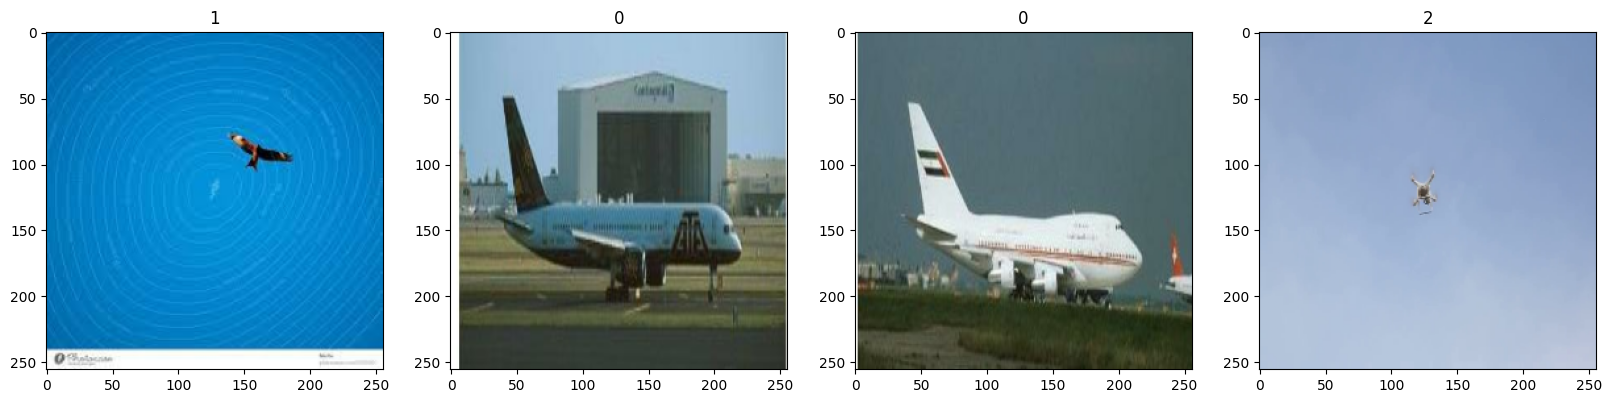

In [6]:
fig,ax=plt.subplots(ncols=4,figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

split data

In [7]:
train_size=int(len(data)*.7)
test_size=int(len(data)*.2)+1
val_size=int(len(data)*.1)+1

In [8]:
train=data.take(train_size)
val=data.skip(train_size).take(val_size)
test=data.skip(train_size+val_size).take(test_size)


model

In [15]:
model=keras.Sequential([
    layers.Conv2D(32,(3,3),1,activation='relu',input_shape=(256,256,3)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

     
     layers.Conv2D(64,(3,3),activation='relu'),
     layers.Conv2D(128,(3,3),activation='relu'),
     layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(50,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(3,activation='softmax')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 252, 252, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 124, 124, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 60, 60, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 58, 58, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 107648)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │     5,382,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,623,499 (21.45 MB)

 Trainable params: 5,623,499 (21.45 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

logdir = 'logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

# Define early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

# Pass BOTH callbacks to model.fit()
history = model.fit(
    train,
    validation_data=val,
    epochs=15,
    callbacks=[tensorboard_callback, early_stopping,reduce_lr]  
)

Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 305s 6s/step - accuracy: 0.3907 - loss: 1.1402 - val_accuracy: 0.6680 - val_loss: 0.7247 - learning_rate: 0.0010
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 290s 6s/step - accuracy: 0.5978 - loss: 0.7898 - val_accuracy: 0.7266 - val_loss: 0.6598 - learning_rate: 0.0010
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.6965 - loss: 0.6840 - val_accuracy: 0.7617 - val_loss: 0.5930 - learning_rate: 0.0010
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.7238 - loss: 0.6292 - val_accuracy: 0.7734 - val_loss: 0.5012 - learning_rate: 0.0010
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 191s 4s/step - accuracy: 0.7378 - loss: 0.5851 - val_accuracy: 0.8320 - val_loss: 0.4895 - learning_rate: 0.0010
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 181s 4s/step - accuracy: 0.7651 - loss: 0.5258 - val_accuracy: 0.8086 - val_loss: 0.4965 - learning_rate: 0.0010
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 207s 4s/step - accuracy: 0.7851 - loss: 0.4882 - val_acc

In [17]:
history.history

{'accuracy': [0.44117647409439087,
  0.623774528503418,
  0.6985294222831726,
  0.7144607901573181,
  0.7420343160629272,
  0.7542892098426819,
  0.7751225233078003,
  0.7990196347236633,
  0.8008578419685364,
  0.8180146813392639,
  0.8290441036224365,
  0.8511029481887817,
  0.8621323704719543,
  0.8529411554336548,
  0.8584558963775635],
 'loss': [1.0270259380340576,
  0.7731725573539734,
  0.6750308871269226,
  0.6274436116218567,
  0.5867835283279419,
  0.5480285882949829,
  0.5066129565238953,
  0.47371479868888855,
  0.4528125822544098,
  0.41699814796447754,
  0.4096352458000183,
  0.3585982918739319,
  0.3256887197494507,
  0.3146187365055084,
  0.308887243270874],
 'val_accuracy': [0.66796875,
  0.7265625,
  0.76171875,
  0.7734375,
  0.83203125,
  0.80859375,
  0.81640625,
  0.7890625,
  0.79296875,
  0.8203125,
  0.8671875,
  0.85546875,
  0.88671875,
  0.8828125,
  0.88671875],
 'val_loss': [0.724716305732727,
  0.6597873568534851,
  0.5930213332176208,
  0.501183331012725

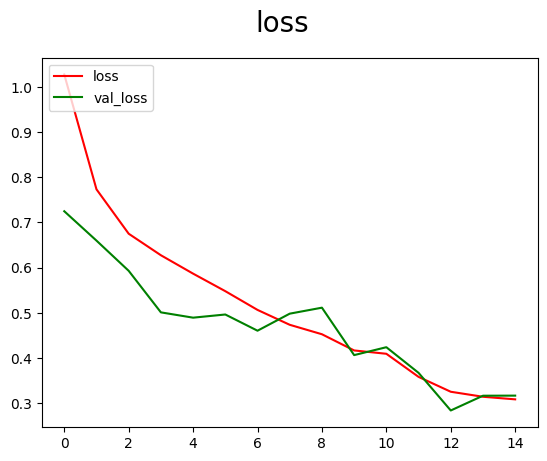

In [26]:
fig=plt.figure()
plt.plot(history.history['loss'],color='red',label='loss')
plt.plot(history.history['val_loss'],color='green',label='val_loss')
fig.suptitle('loss', fontsize=20)
plt.legend(loc='upper left')
plt.show()

In [30]:
len(test)

15

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
✅ Image: C:\Users\Govind Gupta\OneDrive\Desktop\jupyter notebook\OIP-1109473420.jpg
📊 Prediction: Drone
📈 Confidence: 63.40%


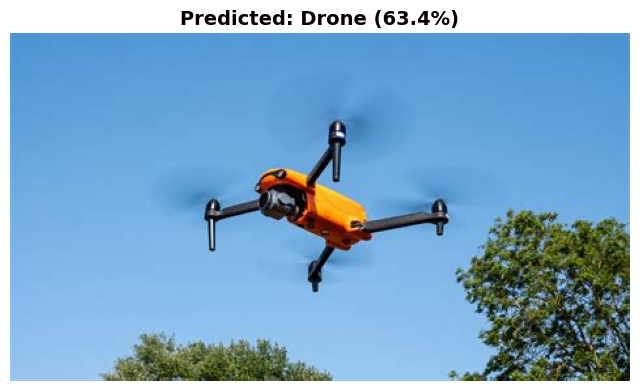

In [39]:
image_path = r"C:\Users\Govind Gupta\OneDrive\Desktop\jupyter notebook\OIP-1109473420.jpg"

img = cv2.imread(image_path)
if img is None:
    print("❌ Error: Could not load image. Check the path.")
else:
    # 2. Convert BGR to RGB (OpenCV reads as BGR)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 3. Resize to match model input (256x256)
    resized = tf.image.resize(img_rgb, (256, 256))
    
    # 4. Scale pixel values to 0-1
    scaled = resized / 255.0
    
    # 5. Add batch dimension (model expects batch of images)
    batch = np.expand_dims(scaled, axis=0)
    
    # 6. Make prediction
    yhat = model.predict(batch)
    predicted_class = np.argmax(yhat)
    confidence = float(np.max(yhat))  # ✅ Convert to Python float
    
    # 7. Map to your class names
    class_names = ['Airplane', 'Birds', 'Drone']
    predicted_label = class_names[predicted_class]
    
    # 8. Display results
    print(f"✅ Image: {image_path}")
    print(f"📊 Prediction: {predicted_label}")
    print(f"📈 Confidence: {confidence * 100:.2f}%")
    
    
    # 9. Show image with prediction
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(f"Predicted: {predicted_label} ({confidence*100:.1f}%)", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

In [20]:
from tensorflow.keras.models import load_model
model.save(os.path.join('JUPYTER NOTEBOOK','Dronedetectionsystem.h5'))